# PduJ Full Site-Saturation Mutagenesis — Structural ΔΔG Landscape

Computes ΔΔG for all 91 positions × 19 non-WT amino acids (1,729 mutants total) in the PduJ hexameric BMC shell protein.

- **WT structure:** `PduJ_mutants/WT_PduJ.pdb` (hexamer, chains A–F)
- **WT baseline:** globally relaxed (full sidechain repack + sidechain-only FastRelax at all backbone positions); cached at `PduJ_SSM_results/WT_relaxed.pdb`
- **SSM targets:** `PduJ_conservation_analysis/PduJ_SSM_targets.csv` (91 positions)
- **Output:** `PduJ_SSM_results/PduJ_SSM_ddg.csv` and pivot matrix `PduJ_SSM_matrix.csv`
- **Checkpoint-safe:** appends results as they complete; re-running skips finished (residue, AA) pairs.
- **No pre-existing data** — all 1,729 mutants are computed fresh.

In [17]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

import pyrosetta
from pyrosetta import *
from pyrosetta.rosetta.core.pose import Pose
from pyrosetta.rosetta.core.import_pose import pose_from_file
from pyrosetta.rosetta.core.scoring import get_score_function
from pyrosetta.rosetta.protocols.relax import FastRelax
from pyrosetta.rosetta.core.kinematics import MoveMap
from pyrosetta.rosetta.core.pack.task import TaskFactory
from pyrosetta.rosetta.core.pack.task.operation import (
    InitializeFromCommandline, OperateOnResidueSubset,
    RestrictAbsentCanonicalAASRLT, RestrictToRepackingRLT,
    PreventRepackingRLT, NoRepackDisulfides,
)
from pyrosetta.rosetta.core.select.residue_selector import (
    ResidueIndexSelector, NeighborhoodResidueSelector,
    NotResidueSelector, AndResidueSelector, OrResidueSelector,
    TrueResidueSelector,
)
from pyrosetta.rosetta.protocols.minimization_packing import PackRotamersMover

In [18]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
WT_PDB          = "PduJ_mutants/WT_PduJ.pdb"
WT_RELAXED_PDB  = "PduJ_SSM_results/WT_relaxed.pdb"   # cached relaxed WT structure
SSM_TARGETS     = "PduJ_conservation_analysis/PduJ_SSM_targets.csv"
OUT_DIR         = Path("PduJ_SSM_results")
CHECKPOINT      = OUT_DIR / "PduJ_SSM_ddg.csv"
RIGOROUS_CSV    = OUT_DIR / "PduJ_SSM_ddg_rigorous.csv"  # per-position local WT baseline
CHAINS          = ["A", "B", "C", "D", "E", "F"]
REPACK_RADIUS   = 10.0
ALL_AAS         = list("ACDEFGHIKLMNPQRSTVWY")

OUT_DIR.mkdir(exist_ok=True)

pyrosetta.init("-mute all -ex1 -ex2")
sf = get_score_function()
print("PyRosetta initialized.")

┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2026 [Rosetta PyRosetta4.Release.python311.m1 2026.03+releasequarterly.5e498f1409c68ade56c8ce5842bf79e1b02e8db4 2026-01-13T13:24:11] retrieved from: http://www.pyrosetta.org
PyRosetta initialized.


In [19]:
def find_target_residues(pose, target_pdb_num, chains):
    targets = {}
    for i in range(1, pose.total_residue() + 1):
        if not pose.pdb_info():
            continue
        chain   = pose.pdb_info().chain(i)
        pdb_num = pose.pdb_info().number(i)
        if chain in chains and pdb_num == target_pdb_num:
            targets[chain] = i
    return targets

def build_union_selector(resnums):
    selectors = [ResidueIndexSelector(str(r)) for r in resnums]
    combined  = selectors[0]
    for sel in selectors[1:]:
        new_or = OrResidueSelector()
        new_or.add_residue_selector(combined)
        new_or.add_residue_selector(sel)
        combined = new_or
    return combined

def mutate_all_chains_with_packing(pose, target_resnums, target_aa_one_letter, sf,
                                   repack_radius=10.0):
    mut_selector = build_union_selector(target_resnums)
    nbr_selector = NeighborhoodResidueSelector()
    nbr_selector.set_focus_selector(mut_selector)
    nbr_selector.set_distance(repack_radius)
    nbr_selector.set_include_focus_in_subset(True)
    nbr_not_mut = AndResidueSelector()
    nbr_not_mut.add_residue_selector(nbr_selector)
    nbr_not_mut.add_residue_selector(NotResidueSelector(mut_selector))
    tf = TaskFactory()
    tf.push_back(InitializeFromCommandline())
    tf.push_back(NoRepackDisulfides())
    restrict_to_aa = RestrictAbsentCanonicalAASRLT()
    restrict_to_aa.aas_to_keep(target_aa_one_letter)
    tf.push_back(OperateOnResidueSubset(restrict_to_aa, mut_selector))
    restrict_repack = RestrictToRepackingRLT()
    tf.push_back(OperateOnResidueSubset(restrict_repack, nbr_not_mut))
    prevent_rlt = PreventRepackingRLT()
    tf.push_back(OperateOnResidueSubset(prevent_rlt, nbr_selector, True))
    packer = PackRotamersMover()
    packer.score_function(sf)
    packer.task_factory(tf)
    packer.apply(pose)
    return pose

def relax_around_mutations(pose, mutated_resnums, radius=10.0):
    sf = get_score_function()
    movemap = MoveMap()
    movemap.set_bb(False)
    movemap.set_chi(False)
    movemap.set_jump(False)
    for i in range(1, pose.total_residue() + 1):
        res = pose.residue(i)
        for mut_resnum in mutated_resnums:
            mut_res = pose.residue(mut_resnum)
            if res.has("CA") and mut_res.has("CA"):
                if res.xyz("CA").distance(mut_res.xyz("CA")) <= radius:
                    movemap.set_chi(i, True)
                    break
    relax = FastRelax()
    relax.set_scorefxn(sf)
    relax.set_movemap(movemap)
    relax.apply(pose)
    return pose

def save_result(row_dict, checkpoint_path):
    df = pd.DataFrame([row_dict])
    df.to_csv(checkpoint_path, mode='a', header=not checkpoint_path.exists(), index=False)

def load_checkpoint(checkpoint_path):
    if checkpoint_path.exists():
        done = pd.read_csv(checkpoint_path)
        return set(zip(done["residue_num"].astype(int), done["mut_aa"]))
    return set()

In [20]:
print("Loading PduJ WT structure...")
wt_pose_raw = Pose()
pose_from_file(wt_pose_raw, WT_PDB)
dG_WT_raw = sf(wt_pose_raw)
print(f"PduJ WT pose: {wt_pose_raw.total_residue()} residues")
print(f"Raw (unrelaxed) WT score: {dG_WT_raw:.3f} REU")

# ── Relax WT to get a proper energy baseline ─────────────────────────────────
# IMPORTANT: Every mutant is scored after sidechain packing + local FastRelax.
# Using the raw crystal structure as the WT baseline creates a systematic
# artifact (raw crystal structures have strained sidechains) that makes
# nearly all mutations appear stabilizing relative to an unrelaxed WT.
# We fix this by applying a full sidechain repack + sidechain-only FastRelax
# across all backbone positions, then caching the result so this only runs once.

if Path(WT_RELAXED_PDB).exists():
    print(f"Loading cached relaxed WT from {WT_RELAXED_PDB} ...")
    wt_pose = Pose()
    pose_from_file(wt_pose, WT_RELAXED_PDB)
else:
    print("Relaxing WT: full sidechain repack + sidechain-only FastRelax (runs once)...")
    wt_pose = wt_pose_raw.clone()

    # Step 1: repack all sidechains across every backbone position (no design)
    tf_wt = TaskFactory()
    tf_wt.push_back(InitializeFromCommandline())
    tf_wt.push_back(NoRepackDisulfides())
    repack_op = RestrictToRepackingRLT()
    tf_wt.push_back(OperateOnResidueSubset(repack_op, TrueResidueSelector()))
    packer = PackRotamersMover()
    packer.score_function(sf)
    packer.task_factory(tf_wt)
    packer.apply(wt_pose)
    print(f"  After repack: {sf(wt_pose):.3f} REU")

    # Step 2: sidechain-only FastRelax at all backbone positions
    mm_wt = MoveMap()
    mm_wt.set_bb(False)    # backbone stays fixed
    mm_wt.set_chi(True)    # all sidechains free
    mm_wt.set_jump(False)
    relax_wt = FastRelax()
    relax_wt.set_scorefxn(sf)
    relax_wt.set_movemap(mm_wt)
    relax_wt.apply(wt_pose)

    # Cache the relaxed structure
    wt_pose.dump_pdb(WT_RELAXED_PDB)
    print(f"  Saved relaxed WT → {WT_RELAXED_PDB}")

dG_WT = sf(wt_pose)
print(f"Relaxed WT score: {dG_WT:.3f} REU  (shift: {dG_WT - dG_WT_raw:+.1f} REU vs raw)")

Loading PduJ WT structure...
PduJ WT pose: 540 residues
Raw (unrelaxed) WT score: -1299.455 REU
Loading cached relaxed WT from PduJ_SSM_results/WT_relaxed.pdb ...
Relaxed WT score: -1497.258 REU  (shift: -197.8 REU vs raw)


In [21]:
targets_df = pd.read_csv(SSM_TARGETS)
done = load_checkpoint(CHECKPOINT)
print(f"Already done: {len(done)} (residue, AA) pairs")

tasks = []
for _, row in targets_df.iterrows():
    resnum = int(row["residue_num"])
    ref_aa = row["ref_aa"]
    for aa in ALL_AAS:
        if aa == ref_aa:
            continue
        if (resnum, aa) not in done:
            tasks.append((resnum, ref_aa, aa))

total_expected = len(targets_df) * 19
print(f"Remaining tasks: {len(tasks)} / {total_expected}")
print(f"Progress: {total_expected - len(tasks)} / {total_expected} complete ({(total_expected - len(tasks)) / total_expected * 100:.1f}%)")

Already done: 1691 (residue, AA) pairs
Remaining tasks: 0 / 1691
Progress: 1691 / 1691 complete (100.0%)


In [22]:
total = len(tasks)
errors = []

for idx, (resnum, ref_aa, mut_aa) in enumerate(tasks):
    label = f"{ref_aa}{resnum}{mut_aa}"
    print(f"[{idx+1}/{total}] {label}...", end=" ", flush=True)
    
    try:
        mut_pose = wt_pose.clone()
        target_res = find_target_residues(mut_pose, resnum, CHAINS)
        
        if len(target_res) == 0:
            print(f"SKIP — residue {resnum} not found in any chain")
            continue
        
        mutated_resnums = list(target_res.values())
        mutate_all_chains_with_packing(mut_pose, mutated_resnums, mut_aa, sf,
                                        repack_radius=REPACK_RADIUS)
        relax_around_mutations(mut_pose, mutated_resnums, radius=REPACK_RADIUS)
        
        dG_mut = sf(mut_pose)
        ddG = dG_mut - dG_WT
        
        result = {
            "residue_num":  resnum,
            "ref_aa":       ref_aa,
            "mut_aa":       mut_aa,
            "mutant_label": label,
            "dG_wt_REU":    dG_WT,
            "dG_mut_REU":   dG_mut,
            "ddG_REU":      ddG,
            "source":       "computed",
        }
        save_result(result, CHECKPOINT)
        print(f"ddG={ddG:+.2f} REU")
        
    except Exception as e:
        print(f"ERROR: {e}")
        errors.append((label, str(e)))

print(f"\nDone. Errors: {len(errors)}")
for lbl, err in errors:
    print(f"  {lbl}: {err}")


Done. Errors: 0


Loaded rigorous CSV (1694 rows) — using per-position WT baseline
  1694 local_relaxed  |  0 global_relaxed (fallback)
Total results: 1694
Unique positions: 89
count    1694.000000
mean      266.652768
std       618.651496
min       -38.888902
25%        33.324187
50%        54.495132
75%       157.595800
max      7610.272794
Name: ddG_rigorous_REU, dtype: float64


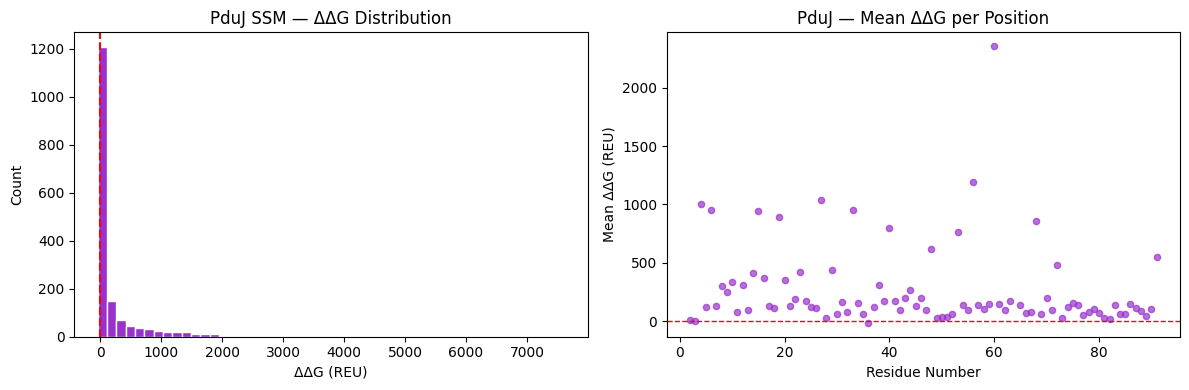

Matrix shape: (89, 20)  (expect 91×20 columns, one NaN per row for WT)


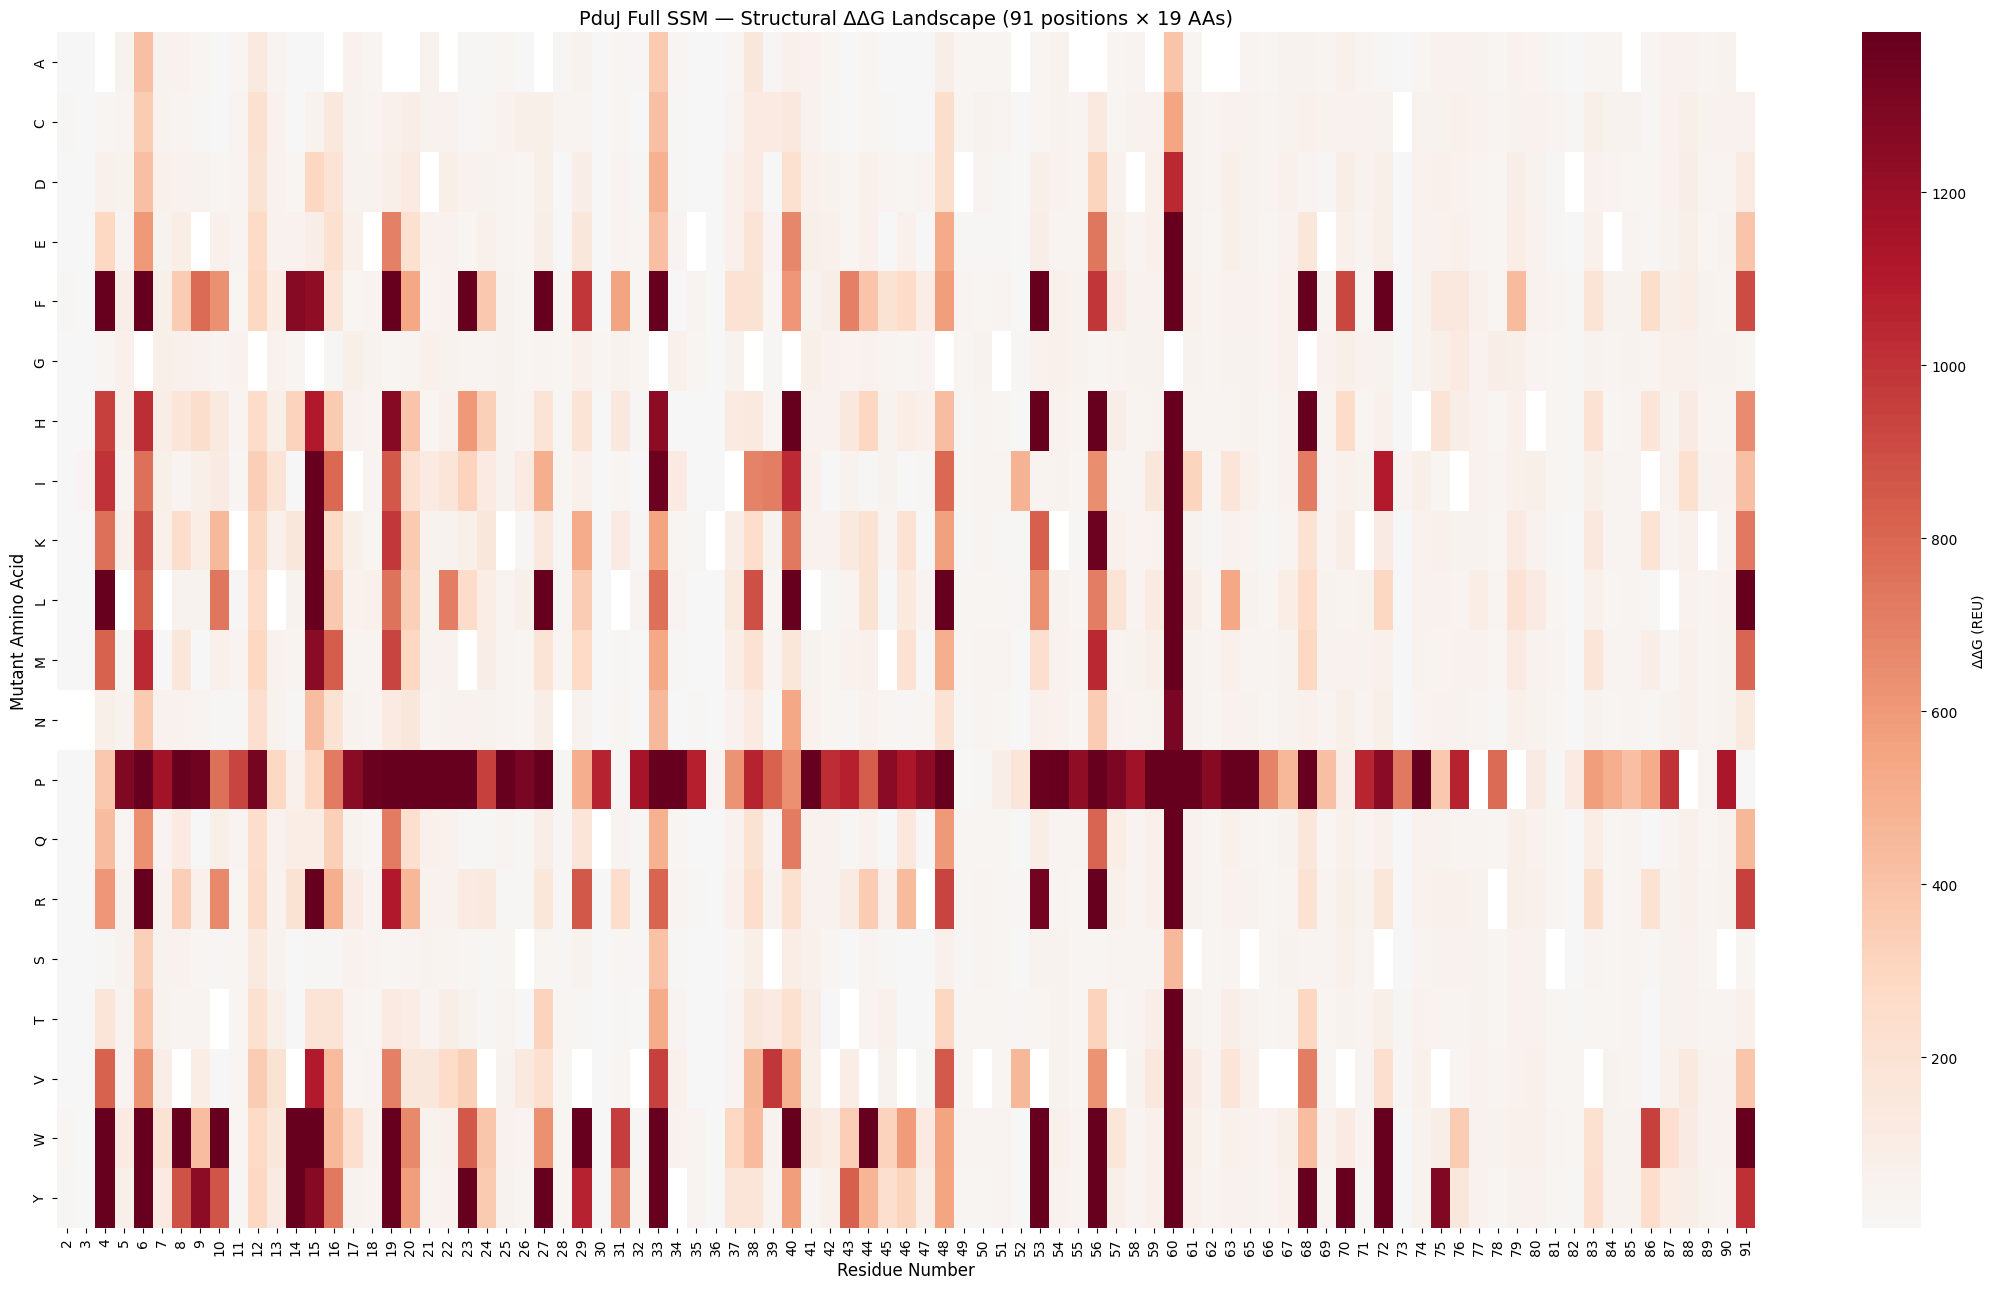

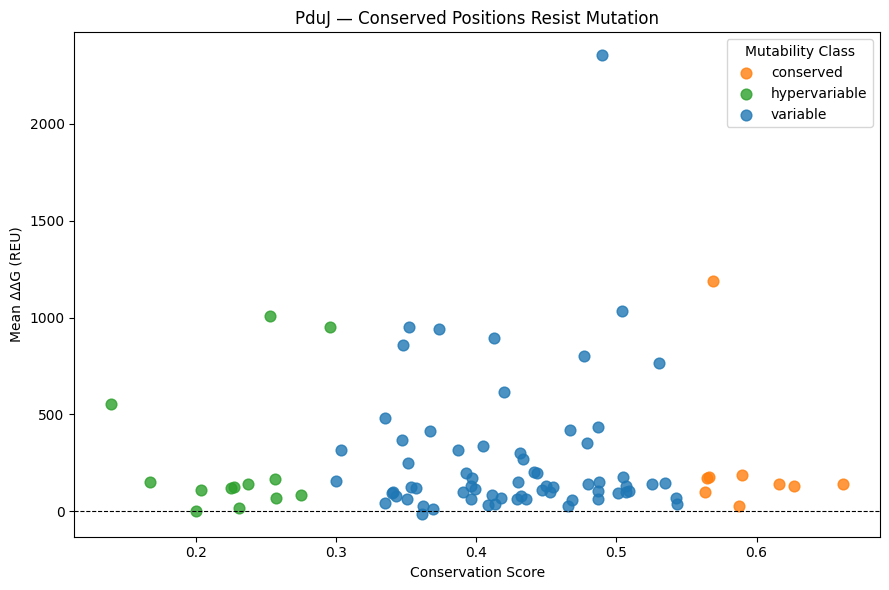

Spearman ρ (conservation vs mean ΔΔG): 0.053  p=0.6225


In [23]:
# Load results: prefer per-position rigorous baseline, fall back to checkpoint CSV
if RIGOROUS_CSV.exists():
    results = pd.read_csv(RIGOROUS_CSV)
    ddg_col = "ddG_rigorous_REU"
    print(f"Loaded rigorous CSV ({len(results)} rows) — using per-position WT baseline")
    n_local  = (results["baseline_type"] == "local_relaxed").sum()
    n_global = (results["baseline_type"] == "global_relaxed").sum()
    print(f"  {n_local} local_relaxed  |  {n_global} global_relaxed (fallback)")
else:
    results = pd.read_csv(CHECKPOINT)
    ddg_col = "ddG_REU"
    print(f"NOTE: per-position baselines not yet computed — run per_position_wt_baselines_pduj.py")
    print(f"Loaded checkpoint CSV ({len(results)} rows) — using global WT baseline (biased)")

targets_df = pd.read_csv(SSM_TARGETS)
if not {"mutability","conservation","mutability_class","rosetta_label"}.issubset(results.columns):
    results = results.merge(targets_df[["residue_num","mutability","conservation",
                                         "mutability_class","rosetta_label"]],
                             on="residue_num", how="left")

print(f"Total results: {len(results)}")
print(f"Unique positions: {results['residue_num'].nunique()}")
print(results[ddg_col].describe())

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(results[ddg_col], bins=50, color="darkorchid", edgecolor="white")
axes[0].axvline(0, color="red", lw=1.5, linestyle="--")
axes[0].set_xlabel("ΔΔG (REU)")
axes[0].set_ylabel("Count")
axes[0].set_title("PduJ SSM — ΔΔG Distribution")

pos_mean = results.groupby("residue_num")[ddg_col].mean().reset_index()
axes[1].scatter(pos_mean["residue_num"], pos_mean[ddg_col], s=20, alpha=0.7, color="darkorchid")
axes[1].axhline(0, color="red", lw=1, linestyle="--")
axes[1].set_xlabel("Residue Number")
axes[1].set_ylabel("Mean ΔΔG (REU)")
axes[1].set_title("PduJ — Mean ΔΔG per Position")
plt.tight_layout()
plt.savefig(OUT_DIR / "PduJ_SSM_QC.png", dpi=150, bbox_inches="tight")
plt.show()

# Pivot matrix
matrix = results.pivot_table(index="residue_num", columns="mut_aa",
                              values=ddg_col, aggfunc="first")
matrix = matrix.reindex(columns=list("ACDEFGHIKLMNPQRSTVWY"))
matrix.to_csv(OUT_DIR / "PduJ_SSM_matrix.csv")
print(f"Matrix shape: {matrix.shape}  (expect 91×20 columns, one NaN per row for WT)")

# Heatmap
fig, ax = plt.subplots(figsize=(22, 13))
vals = matrix.values[~np.isnan(matrix.values)]
if len(vals) > 0:
    vmax = np.percentile(vals, 95)
    vmin = np.percentile(vals, 5)
    sns.heatmap(matrix.sort_index().T, ax=ax, cmap="RdBu_r",
                center=0, vmin=vmin, vmax=vmax,
                linewidths=0, cbar_kws={"label": "ΔΔG (REU)"})
ax.set_xlabel("Residue Number", fontsize=12)
ax.set_ylabel("Mutant Amino Acid", fontsize=12)
ax.set_title("PduJ Full SSM — Structural ΔΔG Landscape (91 positions × 19 AAs)", fontsize=14)
plt.tight_layout()
plt.savefig(OUT_DIR / "PduJ_SSM_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Conservation overlay
pos_stats = results.groupby(["residue_num","conservation","mutability_class"]).agg(
    mean_ddG=(ddg_col,"mean")).reset_index()
colors = {"invariant":"#d62728","conserved":"#ff7f0e","variable":"#1f77b4","hypervariable":"#2ca02c"}
fig, ax = plt.subplots(figsize=(9, 6))
for cls, grp in pos_stats.groupby("mutability_class"):
    ax.scatter(grp["conservation"], grp["mean_ddG"], label=cls,
               color=colors.get(cls,"grey"), s=60, alpha=0.8)
ax.axhline(0, color="black", lw=0.8, linestyle="--")
ax.set_xlabel("Conservation Score")
ax.set_ylabel("Mean ΔΔG (REU)")
ax.set_title("PduJ — Conserved Positions Resist Mutation")
ax.legend(title="Mutability Class")
plt.tight_layout()
plt.savefig(OUT_DIR / "PduJ_SSM_conservation_vs_ddG.png", dpi=150, bbox_inches="tight")
plt.show()

r, p = spearmanr(pos_stats["conservation"], pos_stats["mean_ddG"])
print(f"Spearman ρ (conservation vs mean ΔΔG): {r:.3f}  p={p:.4f}")

## ThermoMPNN Transferability — PduA Model on PduJ

Evaluates how well the PduA fine-tuned ThermoMPNN generalises to PduJ.

- **Model:** PduA fine-tuned checkpoint (`TransferModelPL`, chain A, lightattn)
- **Inference:** full chain A SSM (all positions × 19 AAs), consistent with PduA treatment
- **Comparison:** Spearman ρ vs Rosetta ΔΔG, overall and stratified by conservation class
- **Cache:** `PduJ_SSM_results/PduJ_ThermoMPNN_zeroshot.csv`

In [24]:
# ── ThermoMPNN transferability config ─────────────────────────────────────────
import sys
import torch
from omegaconf import OmegaConf

THERMOMPNN_DIR   = Path("/Users/matthew/Desktop/ThermoMPNN")
sys.path.insert(0, str(THERMOMPNN_DIR))
sys.path.insert(0, str(THERMOMPNN_DIR / "analysis"))

from train_thermompnn import TransferModelPL
from protein_mpnn_utils import alt_parse_PDB
from datasets import Mutation

PDUAJ_MODEL_PATH = "PduA_ThermoMPNN_results/PduA_ThermoMPNN_finetuned.pt"
THERMO_CACHE     = OUT_DIR / "PduJ_ThermoMPNN_zeroshot.csv"

AA20 = list("ACDEFGHIKLMNPQRSTVWY")

thermo_device = torch.device(
    "mps"  if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available() else "cpu"
)
print(f"ThermoMPNN device: {thermo_device}")

ThermoMPNN device: mps


In [25]:
# ── Load PduA fine-tuned checkpoint ──────────────────────────────────────────
thermo_cfg = OmegaConf.create({
    "platform": {"thermompnn_dir": str(THERMOMPNN_DIR)},
    "training": {"num_workers": 0, "learn_rate": 1e-4, "epochs": 20,
                 "lr_schedule": False},
    "model": {
        "hidden_dims": [64, 32],
        "subtract_mut": True,
        "num_final_layers": 2,
        "freeze_weights": True,
        "load_pretrained": True,
        "lightattn": True,
        "lr_schedule": False,
    },
    "decoding_order": "left-to-right",
})

# The checkpoint was saved as torch.save(ft_model.state_dict(), ...) on the inner
# TransferModel — not via PL trainer, so there is no pytorch-lightning_version key.
# Instantiate the PL wrapper, then load weights directly into .model.
print("Loading PduA fine-tuned ThermoMPNN checkpoint...")
ckpt = torch.load(PDUAJ_MODEL_PATH, map_location=thermo_device, weights_only=False)
ft_model_pl = TransferModelPL(cfg=thermo_cfg)
ft_model_pl.model.load_state_dict(ckpt)
ft_model = ft_model_pl.model.to(thermo_device).eval()
print("  Checkpoint loaded.")

# ── Parse PduJ chain A ────────────────────────────────────────────────────────
print(f"Parsing PduJ chain A from {WT_PDB}...")
pduJ_pdb = alt_parse_PDB(WT_PDB, "A")   # returns list; [0] is chain-A dict
chain_seq = pduJ_pdb[0]["seq"]
print(f"  Chain A: {len(chain_seq)} residues")
print(f"  First 10 AA: {chain_seq[:10]}")

# Build PDB residue number → sequential index map for chain A
# alt_parse_PDB stores coords but not explicit PDB numbering; recover from wt_pose_raw
if not wt_pose_raw.pdb_info():
    raise RuntimeError("wt_pose_raw has no PDB info — cannot build residue number map")
pdb_to_seq_idx = {}
seq_idx = 0
for i in range(1, wt_pose_raw.total_residue() + 1):
    chain = wt_pose_raw.pdb_info().chain(i)
    pdb_num = wt_pose_raw.pdb_info().number(i)
    if chain == "A":
        pdb_to_seq_idx[pdb_num] = seq_idx
        seq_idx += 1

seq_idx_to_pdb = {v: k for k, v in pdb_to_seq_idx.items()}
print(f"  PDB residue range: {min(pdb_to_seq_idx)} – {max(pdb_to_seq_idx)}")
assert len(pdb_to_seq_idx) == len(chain_seq),    f"Mismatch: {len(pdb_to_seq_idx)} PDB residues vs {len(chain_seq)} chain A residues"
print("  Sanity check passed: PDB residue count matches chain A length.")

Loading PduA fine-tuned ThermoMPNN checkpoint...
  Checkpoint loaded.
Parsing PduJ chain A from PduJ_mutants/WT_PduJ.pdb...
  Chain A: 90 residues
  First 10 AA: NNALGLVETK
  PDB residue range: 2 – 91
  Sanity check passed: PDB residue count matches chain A length.


/Users/matthew/miniforge3/envs/pyrosetta_env/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `SpearmanCorrcoef` will save all targets and predictions in the buffer. For large datasets, this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


In [26]:
# ── Full chain A SSM inference ────────────────────────────────────────────────
# Runs all positions × 19 AAs on PduJ chain A using the PduA fine-tuned model.
# Results are cached so re-runs are instant.

if THERMO_CACHE.exists():
    print(f"Loading cached ThermoMPNN predictions from {THERMO_CACHE}...")
    thermo_df = pd.read_csv(THERMO_CACHE)
    print(f"  Loaded {len(thermo_df)} predictions.")
else:
    print("Running ThermoMPNN full SSM on PduJ chain A...")
    rows = []
    with torch.no_grad():
        for seq_pos in range(len(chain_seq)):
            wt_aa = chain_seq[seq_pos]
            if wt_aa not in AA20:
                continue
            pdb_num = seq_idx_to_pdb.get(seq_pos, None)
            if pdb_num is None:
                print(f"  WARNING: no PDB number for seq_pos={seq_pos} ({wt_aa}), residue_num will be null in output")
            mutations = [
                Mutation(position=seq_pos, wildtype=wt_aa,
                         mutation=mut_aa, ddG=None)
                for mut_aa in AA20
                if mut_aa != wt_aa
            ]
            preds, _ = ft_model(pduJ_pdb, mutations)
            for mut, pred in zip(mutations, preds):
                if pred is not None:
                    rows.append({
                        "seq_pos":     seq_pos,
                        "residue_num": pdb_num,
                        "ref_aa":      wt_aa,
                        "mut_aa":      mut.mutation,
                        "ddG_thermo":  pred["ddG"].cpu().item(),
                    })

    thermo_df = pd.DataFrame(rows)

    # Assert BEFORE saving to prevent a corrupt cache from being persisted
    n_positions_check = thermo_df["seq_pos"].nunique()
    n_mutations_check = len(thermo_df)
    assert n_mutations_check == n_positions_check * 19, \
        f"Expected {n_positions_check * 19} predictions, got {n_mutations_check}"

    thermo_df.to_csv(THERMO_CACHE, index=False)
    print(f"  Saved {len(thermo_df)} predictions → {THERMO_CACHE}")

n_positions = thermo_df["seq_pos"].nunique()
n_mutations = len(thermo_df)
print(f"  Positions covered: {n_positions}  |  Total predictions: {n_mutations}")
print(f"  ddG_thermo range: [{thermo_df['ddG_thermo'].min():.3f}, {thermo_df['ddG_thermo'].max():.3f}]")
print("  Inference complete.")

Loading cached ThermoMPNN predictions from PduJ_SSM_results/PduJ_ThermoMPNN_zeroshot.csv...
  Loaded 1710 predictions.
  Positions covered: 90  |  Total predictions: 1710
  ddG_thermo range: [-1.016, 8.536]
  Inference complete.


Merged rows: 1694  (expect ~1694 — one per Rosetta mutation)
Overall Spearman ρ (ThermoMPNN vs Rosetta ΔΔG): 0.552  p=5.37e-136  n=1694


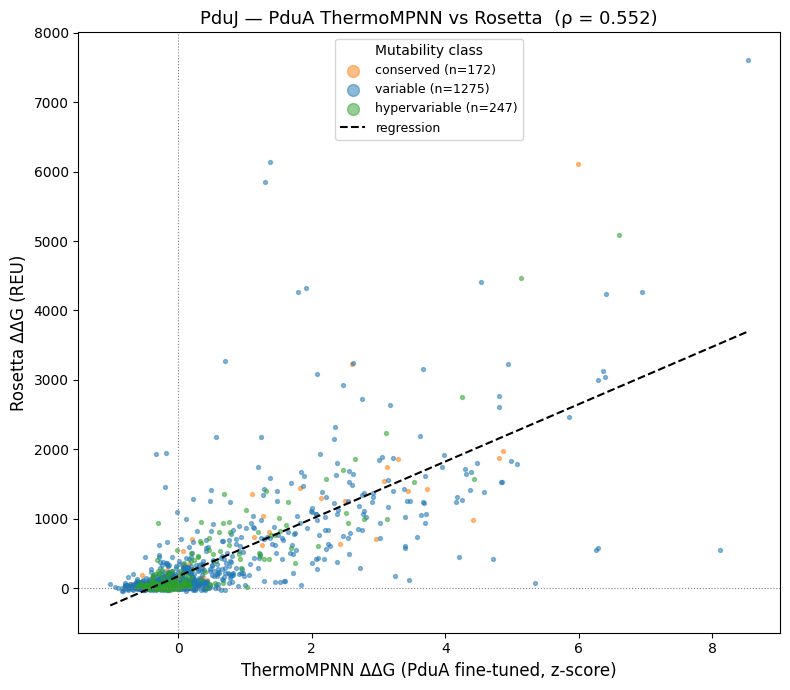

In [27]:
# ── Merge ThermoMPNN predictions with Rosetta ΔΔG ────────────────────────────
# Restrict to the 91 SSM target positions (where Rosetta data exists).
# thermo_df uses residue_num (PDB numbering); results uses residue_num too.

merged = thermo_df.merge(
    results[["residue_num", "mut_aa", ddg_col, "mutability_class", "conservation"]],
    on=["residue_num", "mut_aa"],
    how="inner",
).rename(columns={ddg_col: "ddG_REU"})
print(f"Merged rows: {len(merged)}  (expect ~{len(results)} — one per Rosetta mutation)")
assert len(merged) > 0, "Merge produced 0 rows — check residue_num alignment"
merged = merged.dropna(subset=["ddG_thermo", "ddG_REU"])

# ── Overall Spearman ρ ────────────────────────────────────────────────────────
rho, pval = spearmanr(merged["ddG_thermo"], merged["ddG_REU"])
print(f"Overall Spearman ρ (ThermoMPNN vs Rosetta ΔΔG): {rho:.3f}  p={pval:.2e}  n={len(merged)}")

# ── Scatter plot ──────────────────────────────────────────────────────────────
colors = {
    "invariant":    "#d62728",
    "conserved":    "#ff7f0e",
    "variable":     "#1f77b4",
    "hypervariable": "#2ca02c",
}

fig, ax = plt.subplots(figsize=(8, 7))
CLASS_ORDER = ["invariant", "conserved", "variable", "hypervariable"]
for cls in CLASS_ORDER:
    grp = merged[merged["mutability_class"] == cls]
    if grp.empty:
        continue
    ax.scatter(grp["ddG_thermo"], grp["ddG_REU"],
               color=colors.get(cls, "grey"),
               label=f"{cls} (n={len(grp)})",
               s=8, alpha=0.5)

# Regression line
m, b = np.polyfit(merged["ddG_thermo"], merged["ddG_REU"], 1)
x_line = np.linspace(merged["ddG_thermo"].min(), merged["ddG_thermo"].max(), 200)
ax.plot(x_line, m * x_line + b, color="black", lw=1.5, linestyle="--", label="regression")

ax.axhline(0, color="grey", lw=0.8, linestyle=":")
ax.axvline(0, color="grey", lw=0.8, linestyle=":")
ax.set_xlabel("ThermoMPNN ΔΔG (PduA fine-tuned, z-score)", fontsize=12)
ax.set_ylabel("Rosetta ΔΔG (REU)", fontsize=12)
ax.set_title(f"PduJ — PduA ThermoMPNN vs Rosetta  (ρ = {rho:.3f})", fontsize=13)
ax.legend(title="Mutability class", markerscale=3, fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / "PduJ_ThermoMPNN_vs_Rosetta_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

Conservation-stratified Spearman ρ:
        class    n      rho          pval
    invariant    0      NaN           NaN
    conserved  172 0.523889  1.646691e-13
     variable 1275 0.557550 4.833871e-105
hypervariable  247 0.569452  1.243539e-22


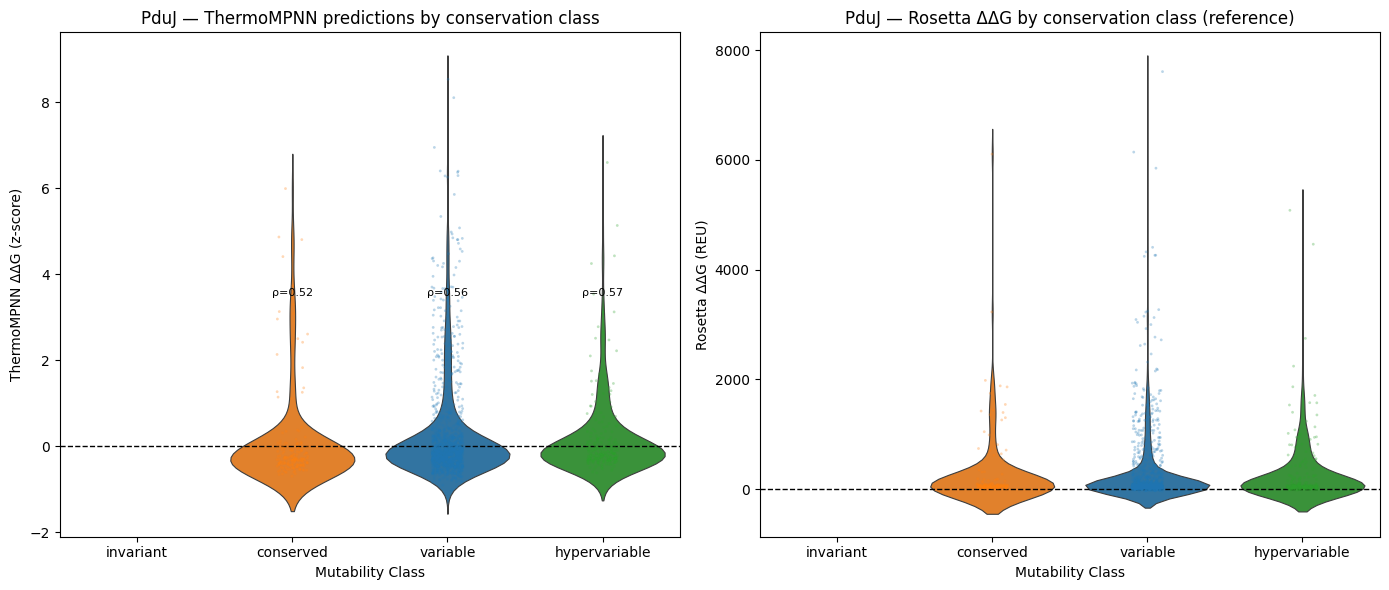

In [28]:
# ── Conservation-stratified Spearman ρ ───────────────────────────────────────
strat_rows = []
for cls in CLASS_ORDER:
    subset = merged[merged["mutability_class"] == cls]
    if len(subset) < 5:
        strat_rows.append({"class": cls, "n": len(subset), "rho": float("nan"), "pval": float("nan")})
        continue
    r, p = spearmanr(subset["ddG_thermo"], subset["ddG_REU"])
    strat_rows.append({"class": cls, "n": len(subset), "rho": r, "pval": p})

strat_df = pd.DataFrame(strat_rows)
print("Conservation-stratified Spearman ρ:")
print(strat_df.to_string(index=False))

# ── Violin + strip plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: ThermoMPNN predictions split by class
sns.violinplot(data=merged, x="mutability_class", y="ddG_thermo",
               order=CLASS_ORDER, hue="mutability_class",
               palette=colors, inner=None, ax=axes[0], linewidth=0.8, legend=False)
sns.stripplot(data=merged, x="mutability_class", y="ddG_thermo",
              order=CLASS_ORDER, hue="mutability_class",
              palette=colors, size=2, alpha=0.3, jitter=True, ax=axes[0], legend=False)
axes[0].axhline(0, color="black", lw=1, linestyle="--")
axes[0].set_xlabel("Mutability Class")
axes[0].set_ylabel("ThermoMPNN ΔΔG (z-score)")
axes[0].set_title("PduJ — ThermoMPNN predictions by conservation class")

# Annotate per-class ρ on plot
for i, cls in enumerate(CLASS_ORDER):
    row = strat_df[strat_df["class"] == cls]
    if not row.empty and not np.isnan(row["rho"].values[0]):
        axes[0].text(i, merged["ddG_thermo"].quantile(0.97),
                     f"ρ={row['rho'].values[0]:.2f}",
                     ha="center", fontsize=8, color="black")

# Right: Rosetta ΔΔG split by class (reference panel)
sns.violinplot(data=merged, x="mutability_class", y="ddG_REU",
               order=CLASS_ORDER, hue="mutability_class",
               palette=colors, inner=None, ax=axes[1], linewidth=0.8, legend=False)
sns.stripplot(data=merged, x="mutability_class", y="ddG_REU",
              order=CLASS_ORDER, hue="mutability_class",
              palette=colors, size=2, alpha=0.3, jitter=True, ax=axes[1], legend=False)
axes[1].axhline(0, color="black", lw=1, linestyle="--")
axes[1].set_xlabel("Mutability Class")
axes[1].set_ylabel("Rosetta ΔΔG (REU)")
axes[1].set_title("PduJ — Rosetta ΔΔG by conservation class (reference)")

plt.tight_layout()
plt.savefig(OUT_DIR / "PduJ_ThermoMPNN_conservation_violin.png", dpi=150, bbox_inches="tight")
plt.show()


In [29]:
# ── Transferability verdict ────────────────────────────────────────────────────
print("=" * 60)
print("PduA → PduJ ThermoMPNN Transferability Summary")
print("=" * 60)
print(f"  Overall Spearman ρ:  {rho:.3f}")

if rho >= 0.4:
    verdict = "GOOD TRANSFER — PduA model generalises to PduJ."
    recommendation = "No immediate need for PduJ-specific fine-tuning."
elif rho >= 0.25:
    verdict = "MODERATE TRANSFER — partial generalisation."
    recommendation = "Consider fine-tuning a PduJ-specific model for better accuracy."
else:
    verdict = "POOR TRANSFER — PduA model does not generalise to PduJ."
    recommendation = ("Fine-tuning recommended: (1) PduJ-specific model, "
                       "(2) combined PduA+PduJ model.")

print(f"\n  Verdict: {verdict}")
print(f"  Recommendation: {recommendation}")

# Conservation signal check: do conserved positions show higher ρ than variable?
cons_rho = strat_df.loc[strat_df["class"].isin(["invariant", "conserved"]), "rho"].mean()
var_rho  = strat_df.loc[strat_df["class"].isin(["variable", "hypervariable"]), "rho"].mean()
print(f"\n  Mean ρ (invariant + conserved):   {cons_rho:.3f}")
print(f"  Mean ρ (variable + hypervariable): {var_rho:.3f}")

if cons_rho > var_rho:
    print("\n  Conserved positions show HIGHER ρ than variable — model captures BMC-H")
    print("  family constraints even across paralogs.")
else:
    print("\n  Conserved positions do NOT show higher ρ than variable — model may be")
    print("  learning PduA-specific rather than BMC-H family features.")
print("=" * 60)

PduA → PduJ ThermoMPNN Transferability Summary
  Overall Spearman ρ:  0.552

  Verdict: GOOD TRANSFER — PduA model generalises to PduJ.
  Recommendation: No immediate need for PduJ-specific fine-tuning.

  Mean ρ (invariant + conserved):   0.524
  Mean ρ (variable + hypervariable): 0.564

  Conserved positions do NOT show higher ρ than variable — model may be
  learning PduA-specific rather than BMC-H family features.
